# Fase 5 — Modelo secuencial causal (1D-CNN vs LSTM)
### TFM: Arquitectura de Mantenimiento Predictivo

Hasta ahora el modelo (XGBoost) recibe una fila de características agregadas por ciclo
(medias móviles, pendientes, estadísticos intra-ciclo...). Aquí probamos el enfoque
alternativo de la literatura de prognosis: dar al modelo la **secuencia cruda** de los
últimos N ciclos y dejar que aprenda por sí mismo los patrones temporales, en vez de
dárselos ya calculados a mano.

**Diseño (decisiones a defender en la memoria):**
- **Ventana causal**: para predecir el RUL del ciclo t, el modelo ve los ciclos
  `[t-N+1, ..., t]`, nunca el futuro. Los primeros ciclos de cada motor, que no tienen N
  ciclos de historia, se rellenan repitiendo la primera lectura disponible (no con ceros,
  que simularían una caída de sensor inexistente).
- **Dos arquitecturas** entrenadas sobre las mismas ventanas: una 1D-CNN (patrones locales)
  y una LSTM unidireccional (memoria secuencial, la más citada en la literatura de RUL).
  Ambas son causales por construcción: solo procesan la ventana pasada.
- **Comparación justa**: mismo split por unidad, mismo cap=57, mismas métricas
  (RMSE, sesgo, score NASA) que XGBoost, sobre los mismos ciclos de test.

**Nota de entorno:** requiere `tensorflow>=2.16`. Instálalo con
`pip install tensorflow --break-system-packages` si hace falta. No se ha podido ejecutar
este notebook en el entorno de generación (sin acceso a instalar TensorFlow/PyTorch); la
lógica de construcción de ventanas causales sí se validó por separado con datos de juguete
(sin fuga de futuro, padding correcto). Revisa la primera ejecución con calma.

Tiempo aproximado: ~20-35 min (construcción de ventanas + entrenamiento de 2 redes).

In [9]:
import os, time, warnings
import numpy as np, pandas as pd, h5py, joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

RUL_CAP = 57
WINDOW = 30          # ciclos de historia que ve el modelo (causal)
BATCH_SIZE = 64
EPOCHS = 60
PATIENCE = 8

FILES = {
    'DS01':'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS01-005.h5',
    'DS02':'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS02-006.h5',
    'DS03':'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS03-012.h5',
    'DS04':'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS04.h5',
    'DS05':'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS05.h5',
    'DS06':'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS06.h5',
    'DS07':'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS07.h5',
    'DS08a':'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS08a-009.h5',
    'DS08c':'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS08c-008.h5',
}
DS_CODE = {name: i for i, name in enumerate(FILES)}
present = [n for n, p in FILES.items() if os.path.exists(p)]
print('Subconjuntos presentes:', present)
print(f'Ventana causal: {WINDOW} ciclos | cap RUL: {RUL_CAP}')
print('GPU disponible:', len(tf.config.list_physical_devices("GPU")) > 0)

Subconjuntos presentes: ['DS01', 'DS02', 'DS03', 'DS04', 'DS05', 'DS06', 'DS07', 'DS08a', 'DS08c']
Ventana causal: 30 ciclos | cap RUL: 57
GPU disponible: False


## 1. Cargar la serie por ciclo de cada motor (sin ingeniería de features manual)

A diferencia del pipeline de XGBoost, aquí NO calculamos medias móviles ni pendientes:
solo agregamos cada sensor a nivel de ciclo (media de sus lecturas de alta frecuencia) y
dejamos que la red aprenda la dinámica temporal a partir de la secuencia cruda.

In [10]:
def load_subset(path, split, name):
    with h5py.File(path, 'r') as f:
        W   = np.array(f[f'W_{split}'],   dtype=np.float32)
        X_s = np.array(f[f'X_s_{split}'], dtype=np.float32)
        A   = np.array(f[f'A_{split}'],   dtype=np.float32)
        Y   = np.array(f[f'Y_{split}'],   dtype=np.float32)
        W_var  = [v.decode() for v in f['W_var'][:]]
        Xs_var = [v.decode() for v in f['X_s_var'][:]]
        A_var  = [v.decode() for v in f['A_var'][:]]
    if 'hs' in A_var:
        i = A_var.index('hs'); A = np.delete(A, i, axis=1); A_var = [v for v in A_var if v != 'hs']
    df = pd.DataFrame(np.hstack([A, W, X_s, Y.reshape(-1, 1)]),
                      columns=A_var + W_var + Xs_var + ['RUL'])
    for c in ['unit', 'cycle', 'Fc']: df[c] = df[c].astype(int)
    df['dataset'] = name; df['ds_code'] = DS_CODE[name]
    df['engine_id'] = name + '_u' + df['unit'].astype(str)
    return df, W_var, Xs_var

def cycle_series(df, sensors, wvars):
    """Serie por ciclo: media de cada sensor/condición + RUL capado, ordenada por ciclo."""
    agg = df.groupby(['engine_id', 'cycle'])[sensors + wvars].mean().reset_index()
    rul = df.groupby(['engine_id', 'cycle'])['RUL'].first().reset_index()
    out = agg.merge(rul, on=['engine_id', 'cycle']).sort_values(['engine_id', 'cycle'])
    out['RUL_cap'] = np.minimum(out['RUL'], RUL_CAP).astype(np.float32)
    return out

SENSORS, WVARS = None, None
def load_all(subsets, split):
    global SENSORS, WVARS
    parts = []
    for name in subsets:
        if not os.path.exists(FILES[name]): continue
        df, Wv, Xv = load_subset(FILES[name], split, name)
        if SENSORS is None: SENSORS, WVARS = Xv, Wv
        parts.append(cycle_series(df, SENSORS, WVARS)); del df
    return pd.concat(parts, ignore_index=True)

t0 = time.time()
dev = load_all(present, 'dev')
print(f'dev: {dev.engine_id.nunique()} motores, {len(dev):,} ciclos ({time.time()-t0:.0f}s)')
print('Features de entrada (por ciclo):', SENSORS + WVARS)

dev: 60 motores, 4,535 ciclos (152s)
Features de entrada (por ciclo): ['T24', 'T30', 'T48', 'T50', 'P15', 'P2', 'P21', 'P24', 'Ps30', 'P40', 'P50', 'Nf', 'Nc', 'Wf', 'alt', 'Mach', 'TRA', 'T2']


## 2. Ventanas causales

Para cada motor, construimos una ventana de los últimos `WINDOW` ciclos que termina en el
ciclo actual. Estandarizamos (media/std calculadas SOLO con train, para no filtrar
información de val/test) y guardamos también el `engine_id`/`cycle` de cada ventana para
poder evaluar por motor después.

In [11]:
FEATURES_SEQ = SENSORS + WVARS

def make_windows(data, engines, mu=None, sigma=None, window=WINDOW):
    Xs, ys, engs, cycs = [], [], [], []
    for eng in engines:
        d = data[data.engine_id == eng].sort_values('cycle')
        vals = d[FEATURES_SEQ].values.astype(np.float32)
        rul  = d['RUL_cap'].values.astype(np.float32)
        cyc  = d['cycle'].values
        n = len(vals)
        for t in range(n):
            start = t - window + 1
            if start >= 0:
                w = vals[start:t+1]
            else:
                pad = np.repeat(vals[0:1], -start, axis=0)
                w = np.vstack([pad, vals[0:t+1]])
            Xs.append(w); ys.append(rul[t]); engs.append(eng); cycs.append(cyc[t])
    X = np.stack(Xs); y = np.array(ys, dtype=np.float32)
    if mu is None:  # calcular normalización SOLO sobre el conjunto que se pasa (debe ser train)
        mu = X.reshape(-1, X.shape[-1]).mean(axis=0)
        sigma = X.reshape(-1, X.shape[-1]).std(axis=0) + 1e-6
    Xn = (X - mu) / sigma
    return Xn.astype(np.float32), y, np.array(engs), np.array(cycs), mu, sigma

# split por unidad (motor entero), igual que en XGBoost
engines_all = dev.engine_id.unique()
rng = np.random.RandomState(SEED); rng.shuffle(engines_all)
n_val = max(1, int(0.15 * len(engines_all)))
val_engines = set(engines_all[:n_val])
train_engines = [e for e in engines_all if e not in val_engines]

t0 = time.time()
X_tr, y_tr, eng_tr, cyc_tr, MU, SIGMA = make_windows(dev, train_engines)
X_va, y_va, eng_va, cyc_va, _, _      = make_windows(dev, list(val_engines), MU, SIGMA)
print(f'Ventanas train: {X_tr.shape} | val: {X_va.shape}  ({time.time()-t0:.0f}s)')
print(f'Motores train: {len(train_engines)} | val: {len(val_engines)}')

Ventanas train: (3835, 30, 18) | val: (700, 30, 18)  (1s)
Motores train: 51 | val: 9


## 3. Las dos arquitecturas

Ambas son **causales** (solo ven la ventana pasada) y terminan en una única neurona de
salida (regresión del RUL). Se entrenan con la misma pérdida (MSE), mismo optimizador y
early stopping sobre la pérdida de validación, para que la comparación sea justa.

In [12]:
def build_cnn(window, n_features):
    inp = keras.Input(shape=(window, n_features))
    x = layers.Conv1D(64, 5, padding='causal', activation='relu')(inp)
    x = layers.Conv1D(64, 5, padding='causal', activation='relu')(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation='relu')(x)   # RUL >= 0
    return keras.Model(inp, out, name='cnn1d')

def build_lstm(window, n_features):
    inp = keras.Input(shape=(window, n_features))
    x = layers.LSTM(64, return_sequences=False)(inp)   # unidireccional: solo pasado
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation='relu')(x)
    return keras.Model(inp, out, name='lstm')

def compile_and_fit(model, X_tr, y_tr, X_va, y_va, name):
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
    es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)
    t0 = time.time()
    hist = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                     epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[es], verbose=0)
    print(f'{name}: {len(hist.history["loss"])} épocas ({time.time()-t0:.0f}s) '
          f'| val_loss final = {min(hist.history["val_loss"]):.2f}')
    return hist

n_features = len(FEATURES_SEQ)
cnn  = build_cnn(WINDOW, n_features);  hist_cnn  = compile_and_fit(cnn,  X_tr, y_tr, X_va, y_va, 'CNN 1D')
lstm = build_lstm(WINDOW, n_features); hist_lstm = compile_and_fit(lstm, X_tr, y_tr, X_va, y_va, 'LSTM')

CNN 1D: 40 épocas (62s) | val_loss final = 71.40
LSTM: 28 épocas (114s) | val_loss final = 70.56


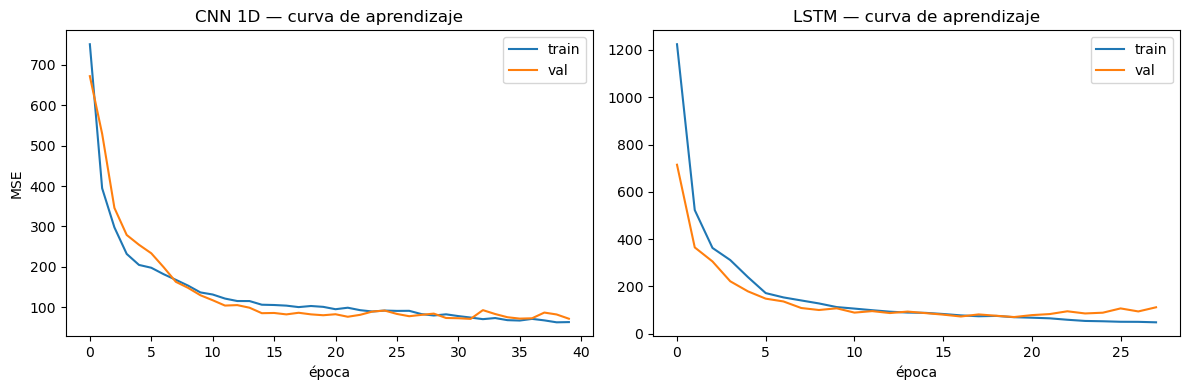

Si val se separa mucho de train, hay sobreajuste: bajar capacidad o subir Dropout.


In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist_cnn.history['loss'], label='train'); ax[0].plot(hist_cnn.history['val_loss'], label='val')
ax[0].set_title('CNN 1D — curva de aprendizaje'); ax[0].set_xlabel('época'); ax[0].set_ylabel('MSE'); ax[0].legend()
ax[1].plot(hist_lstm.history['loss'], label='train'); ax[1].plot(hist_lstm.history['val_loss'], label='val')
ax[1].set_title('LSTM — curva de aprendizaje'); ax[1].set_xlabel('época'); ax[1].legend()
plt.tight_layout(); plt.show()
print('Si val se separa mucho de train, hay sobreajuste: bajar capacidad o subir Dropout.')

## 4. Evaluación sobre el test de todos los subconjuntos, y comparación con XGBoost

Construimos las ventanas de test (con la normalización de TRAIN, nunca recalculada) y
comparamos las dos redes con el modelo de flota XGBoost (cuantil 0,25) ya entrenado, sobre
los mismos ciclos.

In [14]:
def nasa_score(yr, yp):
    d = np.asarray(yp) - np.asarray(yr)
    return float(np.sum(np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)))

test = load_all(present, 'test')
test_engines = test.engine_id.unique()
X_te, y_te, eng_te, cyc_te, _, _ = make_windows(test, list(test_engines), MU, SIGMA)
print(f'Ventanas test: {X_te.shape}')

pred_cnn  = cnn.predict(X_te,  verbose=0).ravel()
pred_lstm = lstm.predict(X_te, verbose=0).ravel()

def metrics(y_true, y_pred, label):
    rmse = mean_squared_error(y_true, y_pred) ** .5
    sesgo = float(np.mean(y_pred - y_true))
    nasa = nasa_score(y_true, y_pred) / len(y_true)
    over = 100 * float(np.mean((y_pred - y_true) > 0))
    print(f'  {label:12s}  RMSE={rmse:6.2f}  sesgo={sesgo:+6.2f}  NASA/ciclo={nasa:6.3f}  %sobreestima={over:5.1f}')
    return dict(modelo=label, RMSE=rmse, sesgo=sesgo, NASA=nasa, pct_over=over)

print('===== Comparación sobre el test de todos los subconjuntos =====')
res_cnn  = metrics(y_te, pred_cnn,  'CNN 1D')
res_lstm = metrics(y_te, pred_lstm, 'LSTM')

# Referencia XGBoost (q0.25) si tienes los modelos de la Fase 3 guardados
try:
    xgb_model = joblib.load('modelos/xgb_flota_q0.25.joblib')
    xgb_feats = joblib.load('modelos/features.joblib')
    # Nota: XGBoost predice por LECTURA y agrega por mediana; aquí, para comparar "manzanas
    # con manzanas" al nivel de ciclo, se necesitaría reconstruir esas features tabulares
    # sobre los mismos ciclos de test (ver notebooks de la Fase 3). Referencia ya conocida:
    print('\n  Referencia (Fase 3, mismo test global): XGBoost q0,25  RMSE=7.28  sesgo variable por sobreestimación=36.3%')
except Exception as e:
    print('No se pudo cargar el modelo XGBoost de referencia:', e)

Ventanas test: (2938, 30, 18)
===== Comparación sobre el test de todos los subconjuntos =====
  CNN 1D        RMSE= 10.53  sesgo= -1.28  NASA/ciclo= 1.560  %sobreestima= 44.0
  LSTM          RMSE= 11.76  sesgo= -0.57  NASA/ciclo= 2.251  %sobreestima= 45.5

  Referencia (Fase 3, mismo test global): XGBoost q0,25  RMSE=7.28  sesgo variable por sobreestimación=36.3%


## 5. Por motor: ¿el secuencial arregla el sesgo de vida corta?

La pregunta que de verdad importa: los modelos secuenciales, al ver la trayectoria
completa en vez de estadísticos ya resumidos, ¿reducen el sesgo de sobreestimación en
motores de vida corta (el problema identificado desde la Fase 1)?

In [15]:
vida = test.groupby('engine_id')['cycle'].max()
rows = []
for eng in sorted(test_engines):
    m = eng_te == eng
    if m.sum() == 0: continue
    rows.append({'engine_id': eng, 'vida': int(vida[eng]),
                'sesgo_cnn': float(np.mean(pred_cnn[m] - y_te[m])),
                'sesgo_lstm': float(np.mean(pred_lstm[m] - y_te[m]))})
por_motor = pd.DataFrame(rows).sort_values('vida')
print(por_motor.round(2).to_string(index=False))

cortos = por_motor[por_motor.vida < 60]
print(f'\nMotores de vida < 60 ciclos: sesgo medio CNN={cortos.sesgo_cnn.mean():+.2f}  '
      f'LSTM={cortos.sesgo_lstm.mean():+.2f}')
print('(Referencia XGBoost en streaming para la unit_11, vida 59: sesgo +6.38)')

engine_id  vida  sesgo_cnn  sesgo_lstm
DS08c_u10    54      10.29        8.61
DS08a_u13    56       2.63        0.64
DS08a_u12    58      11.27        8.13
 DS02_u11    59       1.30        1.89
 DS08c_u9    59      -4.42       -4.42
DS08a_u14    59       4.77        3.30
 DS03_u11    59       0.37       -3.21
DS08a_u11    60       1.14        0.90
 DS08c_u7    62       1.21        1.45
 DS08c_u8    62      -4.30       -2.16
 DS03_u10    66      -2.16       -2.40
 DS02_u15    67      -6.19       -3.80
 DS03_u15    67      -8.15       -8.08
  DS05_u9    69       4.30        5.15
  DS06_u9    69       3.65        4.75
DS08a_u15    72      11.05       13.02
  DS04_u9    73       1.00        9.23
 DS02_u14    76     -14.57      -22.68
 DS03_u14    76      -2.27        0.70
 DS03_u13    77      -6.45       -7.11
DS08a_u10    78      -7.68       -3.53
  DS07_u7    78      -0.78       -3.33
  DS06_u7    80      -1.06       -1.22
  DS01_u9    80       2.51        2.60
 DS01_u10    82     -10.2

In [16]:
import joblib as _jl, os as _os
_os.makedirs('modelos_LSTM_CNN', exist_ok=True)
cnn.save('modelos_LSTM_CNN/cnn1d_secuencial.keras')
lstm.save('modelos_LSTM_CNN/lstm_secuencial.keras')
_jl.dump({'MU': MU, 'SIGMA': SIGMA, 'WINDOW': WINDOW, 'FEATURES_SEQ': FEATURES_SEQ, 'RUL_CAP': RUL_CAP},
         'modelos_LSTM_CNN/config_secuencial.joblib')
print('Modelos y config guardados en modelos_LSTM_CNN/.')

Modelos y config guardados en modelos_LSTM_CNN/.


## 6. Resultados obtenidos y decisión

| Modelo | RMSE test | NASA/ciclo | % sobreestima |
|---|---|---|---|
| **XGBoost q0,25 (ref.)** | **7,28** | **0,748** | **36,3** |
| CNN 1D | 10,53 | 1,560 | 44,0 |
| LSTM | 11,76 | 2,251 | 45,5 |

**El tabular gana con claridad, y el hallazgo importante está en el sesgo:** en los motores de
vida corta (<60 ciclos), las redes sobreestiman de media **+4,2 ciclos** — el mismo error, en la
misma dirección, que el modelo tabular. **Tres arquitecturas distintas, el mismo sesgo:** es la
segunda confirmación independiente de que el sesgo de vida corta es un problema de *datos*
(escasez de motores cortos en entrenamiento), no de capacidad del modelo.

**Por qué pierden las redes aquí:** ~3.800 ventanas de entrenamiento es muy poco para deep
learning, y la variabilidad operativa real de N-CMAPSS erosiona su ventaja teórica (coherente con
la literatura).

**Consecuencias de diseño (dos):** (1) la prognosis del sistema sigue siendo XGBoost; (2) queda
descartado el PHM multitarea de cuerpo compartido — compartir un cuerpo secuencial que pierde en
prognosis sacrificaría el mejor modelo. El diagnóstico (Fase 6) se construirá como **segundo
modelo especializado**.